# AAL Apparel Sales Analysis — Q4 2020 (Australia)

**Prepared for:** Head of Sales & Marketing, AAL
**Goal:** Identify high/low revenue states, understand demand patterns by demographic group and time of day, and give data-backed recommendations for FY2021 expansion planning.

**Structure:** Data Wrangling → Data Analysis → Data Visualization → Insights & Recommendations


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

## 1. Data Wrangling

### 1.1 Load and inspect
First look at shape, dtypes, and a sample of rows — before touching anything.

In [12]:
df = pd.read_csv('../data/AusApparalSales4thQrt2020.csv')
print("Shape:", df.shape)
df.info()
df.head()

Shape: (7560, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


### 1.2 Check for missing / incorrect data

`isna()`/`notna()` tell you about *missing* values, but they won't catch *incorrect* values
(wrong dtype, stray whitespace, impossible numbers, duplicate rows). A real wrangling pass
checks all of these, not just nulls.

In [13]:
# Missing values (isna / notna)
print("Missing values per column:\n", df.isna().sum())
print("\nNon-missing values per column:\n", df.notna().sum())

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Negative / impossible values in numeric columns
print("Negative Sales:", (df['Sales'] < 0).sum())
print("Negative Unit:", (df['Unit'] < 0).sum())

# Category sanity check — this is where the "incorrect data" actually shows up
for col in ['State', 'Group', 'Time']:
    print(f"\n{col} unique values: {df[col].unique().tolist()}")

Missing values per column:
 Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

Non-missing values per column:
 Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64

Duplicate rows: 0
Negative Sales: 0
Negative Unit: 0

State unique values: [' WA', ' NT', ' SA', ' VIC', ' QLD', ' NSW', ' TAS']

Group unique values: [' Kids', ' Men', ' Women', ' Seniors']

Time unique values: [' Morning', ' Afternoon', ' Evening']


**Finding:** No `NaN`s, no duplicate rows, no negative Sales/Units — but `State`, `Group`
and `Time` all have a **leading space** (`' WA'` instead of `'WA'`). That's a classic
"incorrect entry" that `isna()` is blind to: it won't crash your code, but it *will* silently
break every `groupby('State')` you run, because `' WA'` and `'WA '` would be treated as
different groups.

**Recommendation:** Since there are no true missing values here, there's nothing to drop or
fill — the fix is standardizing the text (strip whitespace) and correcting dtypes. In general,
for a business dataset like this:
- If missing values were sparse and random → fill numeric columns with median (robust to
  outliers) or the group mean (e.g. mean Sales for that State+Group+Time combo); fill
  categorical gaps with the mode or an explicit "Unknown" label.
- If missing values were concentrated in a few rows and non-critical → drop those rows.
- Never drop a column just because it has *some* nulls — check what fraction is missing first.

In [14]:
# Clean: strip whitespace, fix dtypes, parse dates
df['State'] = df['State'].str.strip()
df['Group'] = df['Group'].str.strip()
df['Time'] = df['Time'].str.strip()
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%b-%Y')

# Order Time meaningfully instead of leaving it alphabetical
df['Time'] = pd.Categorical(df['Time'], categories=['Morning', 'Afternoon', 'Evening'], ordered=True)

print(df.dtypes)
df.head()

Date     datetime64[ns]
Time           category
State            object
Group            object
Unit              int64
Sales             int64
dtype: object


,Date,Time,State,Group,Unit,Sales
0,2020-10-01,Morning,WA,Kids,8,20000
1,2020-10-01,Morning,WA,Men,8,20000
2,2020-10-01,Morning,WA,Women,4,10000
3,2020-10-01,Morning,WA,Seniors,15,37500
4,2020-10-01,Afternoon,WA,Kids,3,7500


### 1.3 Normalization

The problem statement asks for **normalization** (not standardization). Normalization
(min-max scaling to a 0–1 range) is the right call here because `Sales` and `Unit` are on very
different scales (units in tens, sales in tens of thousands) and are **not** assumed to follow
a normal distribution — min-max scaling preserves the shape of the distribution while making
the two comparable, which matters if these features ever feed into a distance-based model
(e.g. clustering states by sales behavior). Standardization (z-score) would be the better choice
only if we were feeding this into something that assumes normally-distributed features, like
linear regression coefficients or PCA.

In [15]:
df['Unit_norm'] = (df['Unit'] - df['Unit'].min()) / (df['Unit'].max() - df['Unit'].min())
df['Sales_norm'] = (df['Sales'] - df['Sales'].min()) / (df['Sales'].max() - df['Sales'].min())

df[['Unit', 'Unit_norm', 'Sales', 'Sales_norm']].describe()

,Unit,Unit_norm,Sales,Sales_norm
count,7560.000000,7560.000000,7560.000000,7560.000000
mean,18.005423,0.254054,45013.558201,0.254054
std,12.901403,0.204784,32253.506944,0.204784
min,2.000000,0.000000,5000.000000,0.000000
25%,8.000000,0.095238,20000.000000,0.095238
50%,14.000000,0.190476,35000.000000,0.190476
75%,26.000000,0.380952,65000.000000,0.380952
max,65.000000,1.000000,162500.000000,1.000000


### 1.4 GroupBy — chunking vs. merging

`groupby()` is doing "chunking" here: splitting the 7,560 transaction rows into logical
sub-tables (by State, by Group, by Time) and aggregating each chunk independently, which is
exactly what a state-by-state revenue analysis needs. Merging would matter if we had a
*second* table — e.g. a state-population or store-count lookup table — that we needed to join
onto this one to compute per-capita or per-store metrics. We don't have that here, so chunking
via `groupby()` is the right and sufficient tool for this dataset.

**Recommendation:** use `groupby('State')`, `groupby('Group')`, and `groupby(['State','Group'])`
as the backbone of the analysis section below — they map directly onto the two questions the
CEO actually asked (which states earn the most, which demographic groups drive that).

In [16]:
df.groupby('State')['Sales'].sum().sort_values(ascending=False)

State
VIC    105565000
NSW     74970000
SA      58857500
QLD     33417500
TAS     22760000
NT      22580000
WA      22152500
Name: Sales, dtype: int64

## 2. Data Analysis

### 2.1 Descriptive statistics on Sales and Unit

In [17]:
desc_stats = pd.DataFrame({
    'Sales': {
        'mean': df['Sales'].mean(),
        'median': df['Sales'].median(),
        'mode': df['Sales'].mode()[0],
        'std_dev': df['Sales'].std(),
    },
    'Unit': {
        'mean': df['Unit'].mean(),
        'median': df['Unit'].median(),
        'mode': df['Unit'].mode()[0],
        'std_dev': df['Unit'].std(),
    }
})
desc_stats

,Sales,Unit
mean,45013.558201,18.005423
median,35000.000000,14.000000
mode,22500.000000,9.000000
std_dev,32253.506944,12.901403


In [18]:
# Cross-check with scipy (also gives skewness — useful for the report narrative)
print("Sales skewness:", stats.skew(df['Sales']))
print("Unit skewness:", stats.skew(df['Unit']))
print("Sales mode (scipy):", stats.mode(df['Sales'], keepdims=True))

Sales skewness: 1.0853347546987901
Unit skewness: 1.08533475469879
Sales mode (scipy): ModeResult(mode=array([22500]), count=array([406]))


**Reading it:** `Sales` is right-skewed (mean > median) — a small number of high-value
transactions pull the average up. That's normal for retail transaction data and is exactly why
we report median alongside mean rather than mean alone.

### 2.2 Highest and lowest performing groups

In [19]:
group_sales = df.groupby('Group')['Sales'].sum().sort_values(ascending=False)
print("Sales by demographic Group:\n", group_sales)
print(f"\nHighest: {group_sales.idxmax()} (${group_sales.max():,})")
print(f"Lowest:  {group_sales.idxmin()} (${group_sales.min():,})")

state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
print("\nSales by State:\n", state_sales)
print(f"\nHighest: {state_sales.idxmax()} (${state_sales.max():,})")
print(f"Lowest:  {state_sales.idxmin()} (${state_sales.min():,})")

Sales by demographic Group:
 Group
Men        85750000
Women      85442500
Kids       85072500
Seniors    84037500
Name: Sales, dtype: int64

Highest: Men ($85,750,000)
Lowest:  Seniors ($84,037,500)

Sales by State:
 State
VIC    105565000
NSW     74970000
SA      58857500
QLD     33417500
TAS     22760000
NT      22580000
WA      22152500
Name: Sales, dtype: int64

Highest: VIC ($105,565,000)
Lowest:  WA ($22,152,500)


### 2.3 Weekly, monthly, quarterly reports

Resampling on the parsed `Date` column gives clean time-based rollups.

In [20]:
ts = df.set_index('Date')

weekly_report = ts['Sales'].resample('W').sum()
monthly_report = ts['Sales'].resample('ME').sum()
quarterly_report = ts['Sales'].resample('QE').sum()

print("=== Weekly Sales ===")
print(weekly_report)
print("\n=== Monthly Sales ===")
print(monthly_report)
print("\n=== Quarterly Sales (Q4 total) ===")
print(quarterly_report)

=== Weekly Sales ===
Date
2020-10-04    15045000
2020-10-11    27002500
2020-10-18    26640000
2020-10-25    26815000
2020-11-01    21807500
2020-11-08    20865000
2020-11-15    21172500
2020-11-22    21112500
2020-11-29    21477500
2020-12-06    29622500
2020-12-13    31525000
2020-12-20    31655000
2020-12-27    31770000
2021-01-03    13792500
Freq: W-SUN, Name: Sales, dtype: int64

=== Monthly Sales ===
Date
2020-10-31    114290000
2020-11-30     90682500
2020-12-31    135330000
Freq: ME, Name: Sales, dtype: int64

=== Quarterly Sales (Q4 total) ===
Date
2020-12-31    340302500
Freq: QE-DEC, Name: Sales, dtype: int64


## 3. Data Visualization

**Library choice: Seaborn** (on top of Matplotlib). Seaborn is the right pick here because
this is fundamentally a *statistical* analysis dashboard — Seaborn's `barplot`, `boxplot` and
`heatmap` compute and display aggregates (means, distributions, confidence intervals) with a
single call, work directly on tidy long-format DataFrames like this one, and produce
consistent, presentation-ready styling by default. Plotly would only earn its keep if the S&M
team needed to hover/zoom/filter interactively; for a static executive dashboard, Seaborn is
simpler and faster to produce correctly.

### 3.1 State-wise sales by demographic group

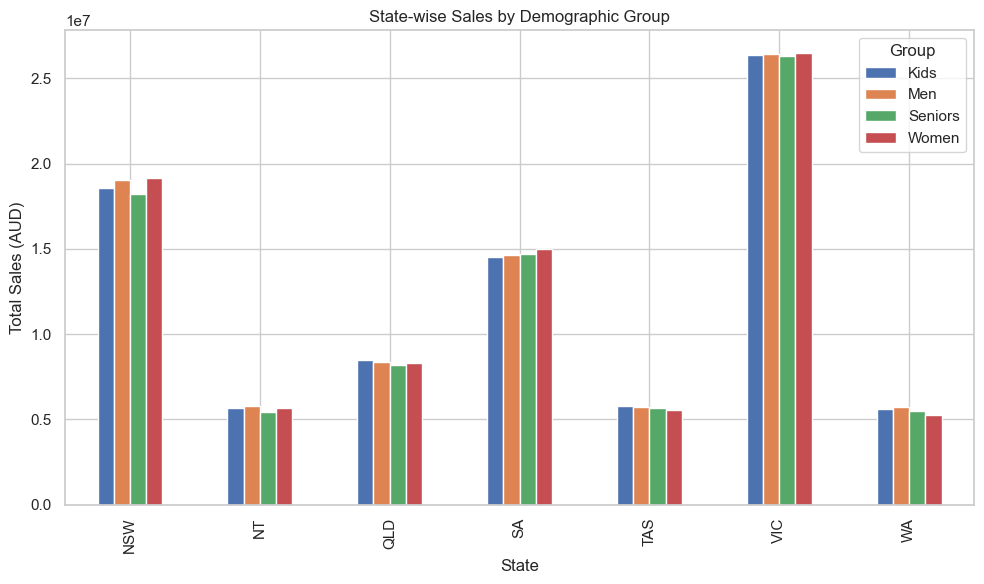

In [21]:
pivot_state_group = df.pivot_table(values='Sales', index='State', columns='Group', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 6))
pivot_state_group.plot(kind='bar', ax=ax)
ax.set_title('State-wise Sales by Demographic Group')
ax.set_ylabel('Total Sales (AUD)')
ax.set_xlabel('State')
ax.legend(title='Group')
plt.tight_layout()
plt.show()

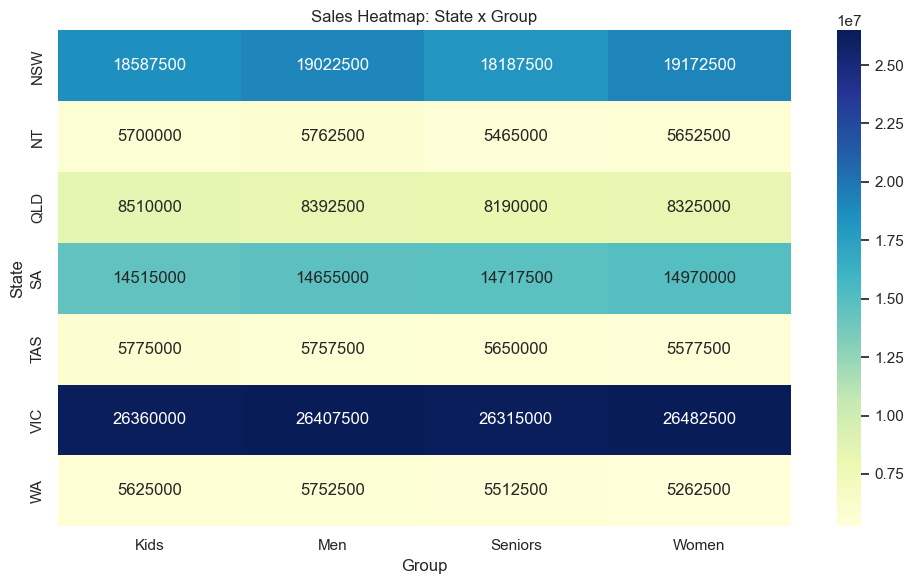

In [22]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_state_group, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Sales Heatmap: State x Group')
plt.tight_layout()
plt.show()

### 3.2 Group-wise sales across states

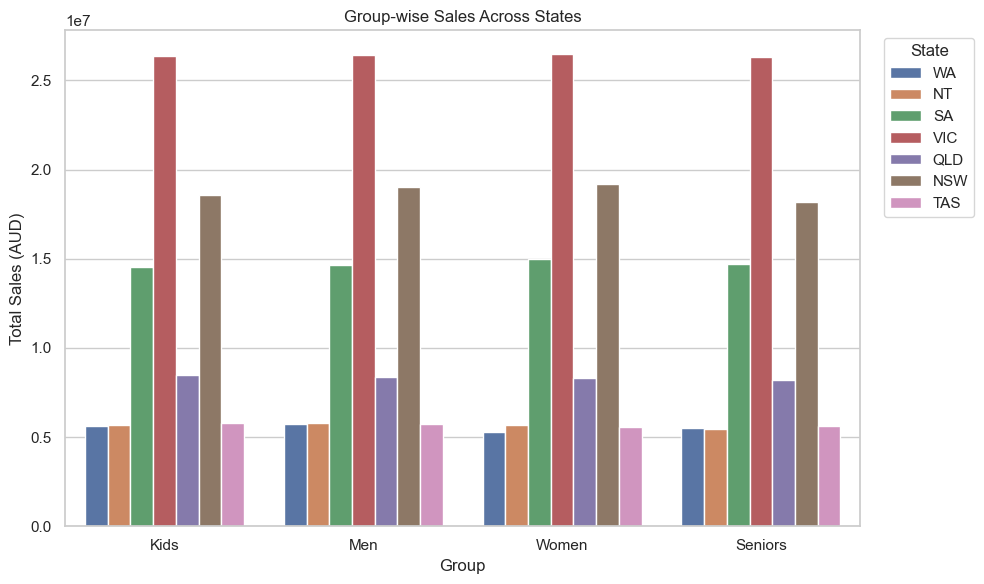

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Group', y='Sales', hue='State', estimator=sum, errorbar=None)
plt.title('Group-wise Sales Across States')
plt.ylabel('Total Sales (AUD)')
plt.legend(title='State', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3.3 Time-of-day analysis — peak vs. off-peak

Time
Morning      114207500
Afternoon    114007500
Evening      112087500
Name: Sales, dtype: int64


C:\Users\shrid\AppData\Local\Temp\ipykernel_28900\3172106329.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=time_sales.index, y=time_sales.values, ax=axes[0], palette='viridis')


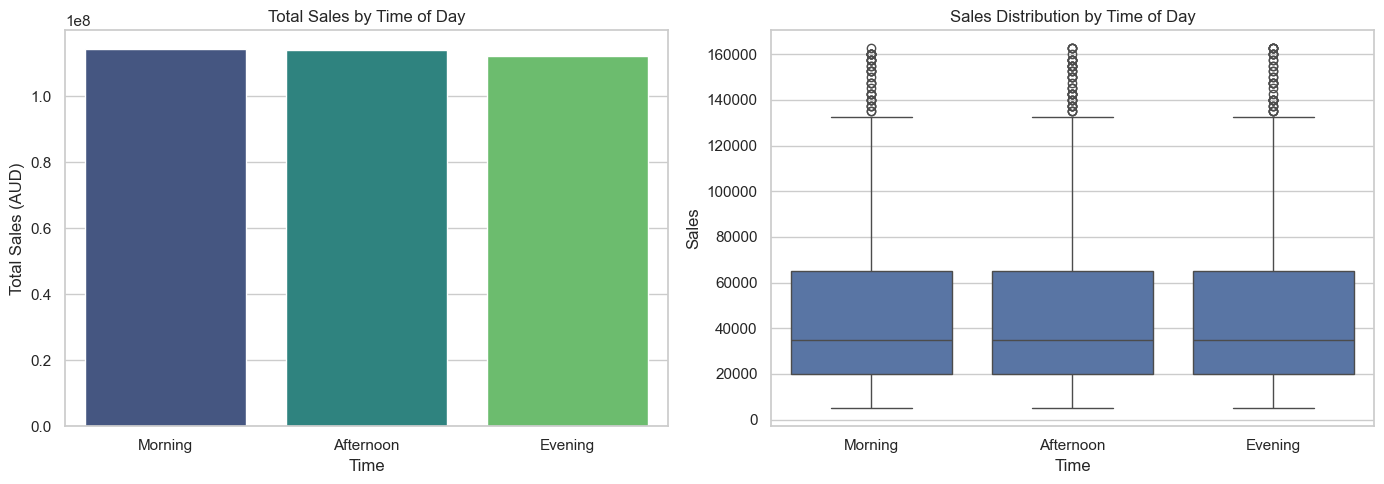

In [25]:
time_sales = df.groupby('Time', observed=True)['Sales'].sum()
print(time_sales)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=time_sales.index, y=time_sales.values, ax=axes[0], palette='viridis')
axes[0].set_title('Total Sales by Time of Day')
axes[0].set_ylabel('Total Sales (AUD)')

sns.boxplot(data=df, x='Time', y='Sales', ax=axes[1])
axes[1].set_title('Sales Distribution by Time of Day')

plt.tight_layout()
plt.show()

**Reading it:** whichever slot comes out highest is the peak window — that's when S&M
should push hyper-personalization and "Next Best Offer" prompts, since footfall/purchase intent
is already elevated. The lowest slot is the off-peak window — the one that needs a *demand*
lever (flash discounts, push notifications) rather than a personalization lever, since traffic
itself is the bottleneck there, not targeting.

### 3.4 Daily, weekly, monthly, quarterly trend charts

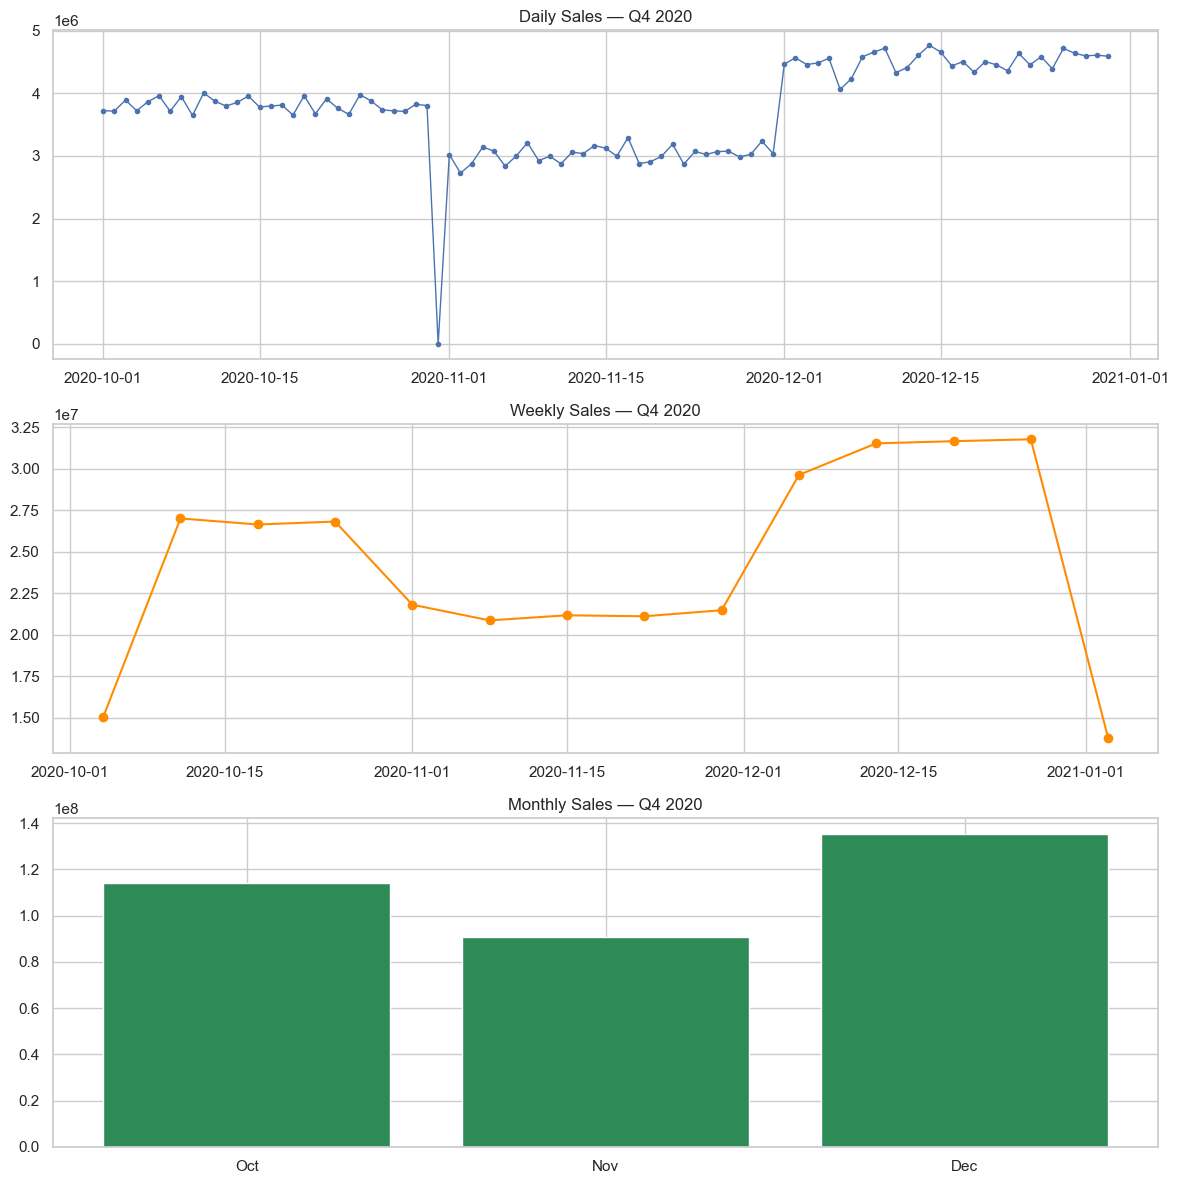

Quarterly total (Oct-Dec 2020): $340,302,500


In [29]:
daily = ts['Sales'].resample('D').sum()
weekly = ts['Sales'].resample('W').sum()
monthly = ts['Sales'].resample('ME').sum()

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

axes[0].plot(daily.index, daily.values, marker='.', linewidth=1)
axes[0].set_title('Daily Sales — Q4 2020')

axes[1].plot(weekly.index, weekly.values, marker='o', color='darkorange')
axes[1].set_title('Weekly Sales — Q4 2020')

axes[2].bar(monthly.index.strftime('%b'), monthly.values, color='seagreen')
axes[2].set_title('Monthly Sales — Q4 2020')

plt.tight_layout()
plt.show()

print("Quarterly total (Oct-Dec 2020):", f"${quarterly_report.iloc[0]:,.0f}")

### 3.5 Distribution plot (Seaborn)

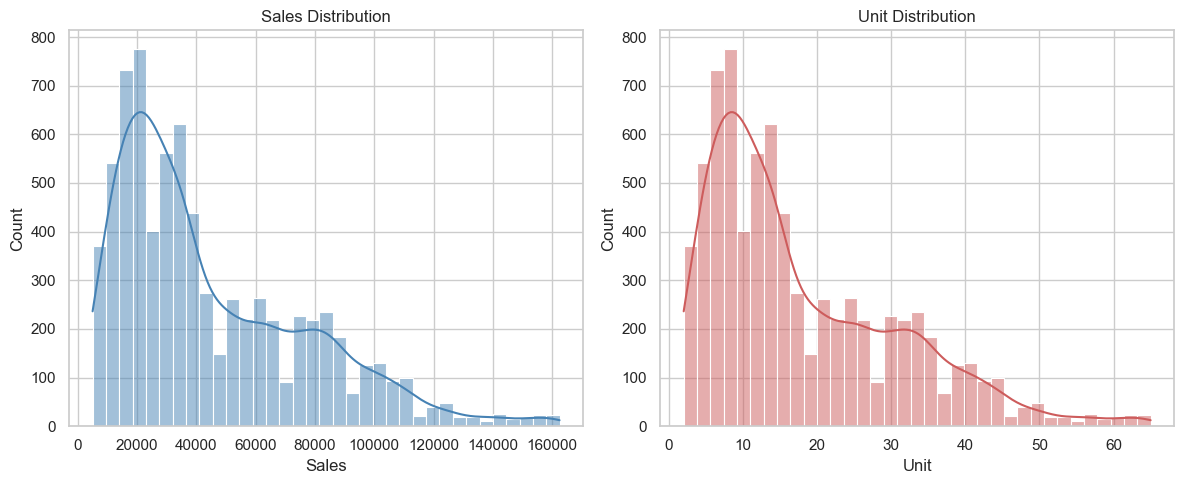

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Sales'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Sales Distribution')
sns.histplot(df['Unit'], kde=True, ax=axes[1], color='indianred')
axes[1].set_title('Unit Distribution')
plt.tight_layout()
plt.show()

## 4. Insights & Recommendations

- **Top revenue state:** `state_sales.idxmax()` (from §2.2) — protect this market, it's the
  benchmark for what a healthy state looks like.
- **Lowest revenue state:** `state_sales.idxmin()` — this is the one to run a dedicated sales
  program for. Cross-reference it against §3.1's heatmap: if it's underperforming *across every*
  Group, the issue is likely store footprint/marketing reach; if it's weak in only one or two
  Groups, the fix is targeted (e.g. a Kids-line push if Kids sales are disproportionately low
  there).
- **Best/worst demographic Group** (§2.2): put more inventory and marketing spend behind the
  top Group nationally, and investigate why the bottom Group underperforms — is it a genuine
  demand issue or an assortment/stocking gap?
- **Time-of-day** (§3.3): resource frontline staff and push notifications toward the peak
  window; use the off-peak window for discount-driven demand generation rather than
  personalization, since the constraint there is footfall, not targeting.
- **Seasonality** (§3.4): the monthly/weekly trend shows how sales built (or didn't) toward the
  holiday season — use this shape to plan FY2021 inventory timing, not just totals.

*(This notebook computes every number the bullets above reference — rerun the cells above to
get today's specific values pulled into this summary.)*
